In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("imports done")

imports done


In [2]:
df = pd.read_csv("../data/paysim.csv")

print(f"Shape: {df.shape}")
print(f"Transactions: {len(df):,}")
print(f"Unique sending accounts: {df['nameOrig'].nunique():,}")
print(f"Steps (hours simulated): {df['step'].max()}")
df.head()

Shape: (6362620, 11)
Transactions: 6,362,620
Unique sending accounts: 6,353,307
Steps (hours simulated): 743


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
print(df.isnull().sum())
print("\n")
print(df.dtypes)
print("\n")
df.describe()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object




,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


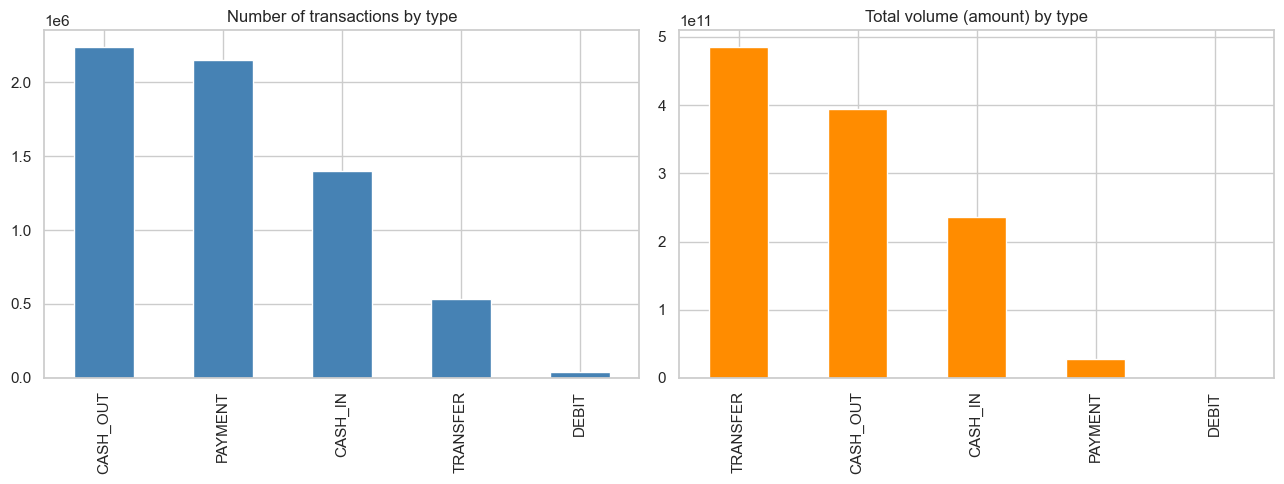

In [4]:
type_counts = df["type"].value_counts()
type_amounts = df.groupby("type")["amount"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

type_counts.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Number of transactions by type")
axes[0].set_xlabel("")

type_amounts.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Total volume (amount) by type")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

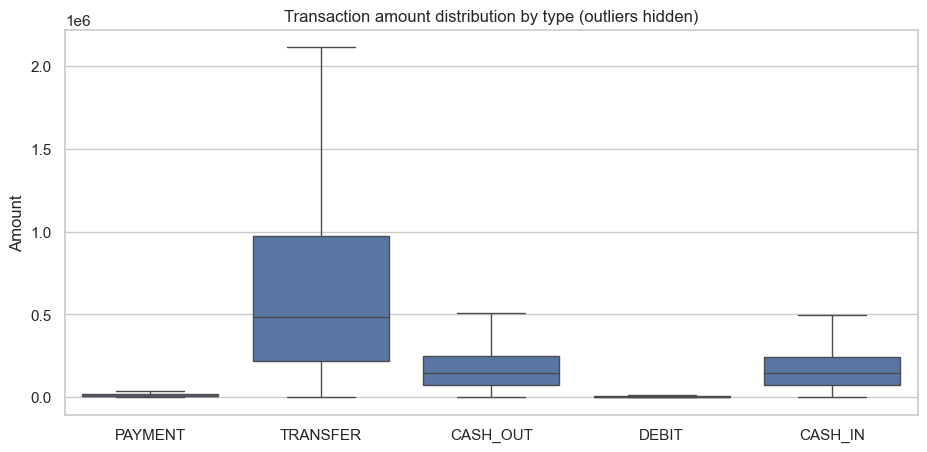

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x="type", y="amount", showfliers=False, ax=ax)
ax.set_title("Transaction amount distribution by type (outliers hidden)")
ax.set_xlabel("")
ax.set_ylabel("Amount")
plt.show()

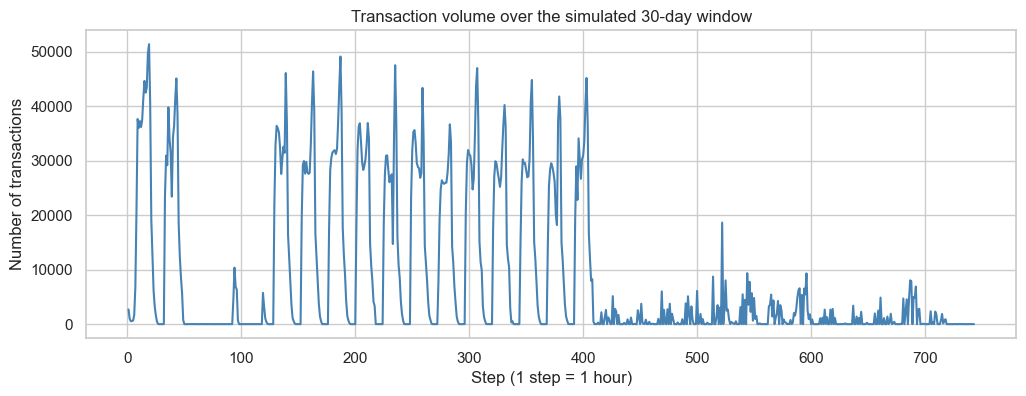

In [6]:
tx_per_step = df.groupby("step").size()

tx_per_step.plot(figsize=(12, 4), color="steelblue")
plt.title("Transaction volume over the simulated 30-day window")
plt.xlabel("Step (1 step = 1 hour)")
plt.ylabel("Number of transactions")
plt.show()

In [7]:
print("Fraud rate overall:")
print(df["isFraud"].value_counts(normalize=True).rename({0: "legit", 1: "fraud"}))

print("\nFraud by transaction type:")
print(df.groupby("type")["isFraud"].mean().sort_values(ascending=False).round(4))

Fraud rate overall:
isFraud
legit    0.998709
fraud    0.001291
Name: proportion, dtype: float64

Fraud by transaction type:
type
TRANSFER    0.0077
CASH_OUT    0.0018
CASH_IN     0.0000
DEBIT       0.0000
PAYMENT     0.0000
Name: isFraud, dtype: float64
